In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

In [190]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def add_gaussian_noise(image, mean=0, var=1):
    """Add Gaussian noise to the image."""
    sigma = var ** 0.5
    gaussian = np.random.normal(mean, sigma, image.shape).astype('uint8')
    noisy_image = cv2.add(image, gaussian)
    return noisy_image

def add_blur(image, ksize=(1, 1)):
    """Add slight blurring to simulate scanning."""
    blurred_image = cv2.GaussianBlur(image, ksize, 0)
    return blurred_image

def adjust_brightness_contrast(image, alpha=0.12, beta=1):
    """Adjust brightness and contrast."""
    adjusted_image = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)
    return adjusted_image

def add_speckles(image, amount=0.00005):
    """Add speckles/dirt marks to the image."""
    output = image.copy()
    num_speckles = int(amount * image.size)
    coords = [np.random.randint(0, i - 1, num_speckles) for i in image.shape]
    output[coords[0], coords[1]] = 0
    return output

def apply_perspective_transform(image):
    """Apply slight perspective transformation to simulate misalignment."""
    rows, cols = image.shape[:2]

    src_points = np.float32([[0, 0], [cols, 0], [0, rows], [cols, rows]])
    dst_points = np.float32([[5, 5], [cols - 10, 10], [10, rows - 5], [cols - 5, rows - 10]])

    matrix = cv2.getPerspectiveTransform(src_points, dst_points)
    transformed_image = cv2.warpPerspective(image, matrix, (cols, rows))

    return transformed_image

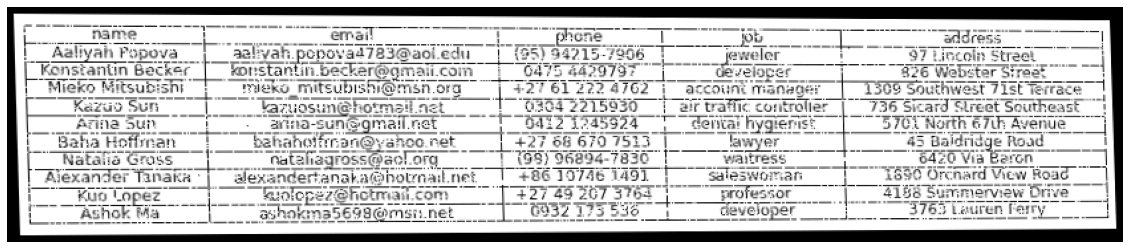

True

In [192]:
# Scanify Example
image_path = './data/pii_img/img_0.png'  # Replace with your image path
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Apply the effects
noisy_image = add_gaussian_noise(image)
#blurred_image = add_blur(noisy_image)
adjusted_image = adjust_brightness_contrast(noisy_image)
#adjusted_image = adjust_brightness_contrast(blurred_image)
speckled_image = add_speckles(adjusted_image)
scanned_image = apply_perspective_transform(speckled_image)

# Display the result
plt.figure(figsize=(20,10))
plt.imshow(scanned_image, cmap='gray')
#plt.title('Scanned Document Effect')
plt.axis('off')
plt.show()

# Save the result
cv2.imwrite('scanned_document_effect.png', scanned_image)

In [ ]:
# Generate Dataset
path = './data/pii_img/'
new_path = './data/pii_img_scan/'
os.makedirs(new_path)
for img_name in os.listdir(path):
    image_path = path+ img_name #'./data/pii_img/img_0.png'  # Replace with your image path
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Apply the effects
    noisy_image = add_gaussian_noise(image)
    #blurred_image = add_blur(noisy_image)
    adjusted_image = adjust_brightness_contrast(noisy_image)
    #adjusted_image = adjust_brightness_contrast(blurred_image)
    speckled_image = add_speckles(adjusted_image)
    scanned_image = speckled_image
    #scanned_image = apply_perspective_transform(speckled_image)

    # Display the result
    plt.figure(figsize=(20,10))
    plt.imshow(scanned_image, cmap='gray')
    #plt.title('Scanned Document Effect')
    plt.axis('off')
    #plt.show()

    # Save the result
    cv2.imwrite(new_path + img_name, scanned_image)